## Setup

In [1]:
!git clone --branch 1-ddpm-implementation https://github.com/GoharKhachatryan/GenAI_project.git

Cloning into 'GenAI_project'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 98 (delta 48), reused 47 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 337.70 KiB | 8.24 MiB/s, done.
Resolving deltas: 100% (48/48), done.


In [2]:
%cd GenAI_project

/content/GenAI_project


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ln -s /content/drive/MyDrive/for_bostongene/data /content/GenAI_project/data
!ln -s /content/drive/MyDrive/for_bostongene/dataset.pt /content/GenAI_project/dataset.pt

In [5]:
%cd /content/GenAI_project/

/content/GenAI_project


## Conditional DDPM training

I have decided to implement the training loop in a notebook for a better visualization and use.

This notebook trains a conditional DDPM on the paired CIFAR-10 dataset.

The denoising model predicts the Gaussian noise added to an image at
a randomly sampled diffusion timestep. The model is conditioned on a
16-dimensional vector derived deterministically from the corresponding
clean image.

A cosine noise schedule with T=1000 diffusion steps is used.

## Imports

In [6]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
from torch.utils.data import DataLoader

from prepare_dataset import PairedCIFAR10

from scripts.unet import UNet
from scripts.model import ConditionalDenoiser
from scripts.diffusion import DDPM

In [7]:
# In case you want to reproduce the training process
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Device selection

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Load datasets

In [9]:
train_dataset = PairedCIFAR10("train")
val_dataset = PairedCIFAR10("val")
test_dataset = PairedCIFAR10("test")

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset),
)

45000 5000 10000


## Condition Normalization

In [10]:
# Based on the condition analysis, they need to be normalized
# feature-wise before feeding to the model
train_conds = torch.stack([
    train_dataset[i][1]
    for i in range(len(train_dataset))
])

# To prevent data leakage, use the statistics from the training set,
# to normalize all of the sets
cond_mean = train_conds.mean(dim=0)
cond_std = train_conds.std(dim=0)

print("Condition mean:")
print(cond_mean)

print("\nCondition std:")
print(cond_std)

Condition mean:
tensor([ 1.6590e+01,  1.5525e+01,  1.4583e+01,  1.4828e+01,  1.5473e+01,
         1.5303e+01,  1.5303e+01,  1.5448e+01,  4.9124e-01,  4.8195e-01,
         4.4636e-01,  1.9618e-01, -5.2558e-09, -3.2213e-09, -3.7723e-09,
         2.3736e-09])

Condition std:
tensor([6.6494, 4.4762, 4.0474, 5.3317, 5.0976, 3.8374, 3.8600, 5.0750, 0.1283,
        0.1257, 0.1531, 0.0601, 1.0000, 1.0000, 1.0000, 1.0000])


In [11]:
cond_mean = cond_mean.to(device)
cond_std = cond_std.to(device)

In [12]:
def normalize_condition(cond):
    return (cond - cond_mean) / (cond_std + 1e-8)

In [13]:
# Save these statistics, since they will be used for the generation
torch.save(
    {
        "mean": cond_mean.cpu(),
        "std": cond_std.cpu(),
    },
    "cond_stats.pt",
)

## DataLoaders

In [14]:
# For a T4
# In case of OOM, change into 64 or lower
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

## Defininig the full model

In [15]:
# Creating the UNet model...
unet = UNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    emb_dim=256,
)

# ...and the conditional denoiser
model = ConditionalDenoiser(
    unet=unet,
    time_dim=256,
    cond_dim=16,
    emb_dim=256,
)

model = model.to(device)

In [16]:
# Since the task has a given range of parameters (3 - 10M parameters),
# checking here if my model is within the given range
num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total trainable parameters: "
    f"{num_params / 1e6:.2f}M"
)

Total trainable parameters: 9.22M


In [17]:
# Manually implemented DDPM
ddpm = DDPM(
    timesteps=1000,
    schedule="cosine",
    device=device,
)

In [18]:
# A basic optimizer for now
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

## Sanity check

This part was to check the full training loop before starting to train on the train set.

It takes one batch and overfits the model on it. The loss is decreasing, which means that the overall flow of the model is correct.

Ignore this during the training.

In [18]:
# take one batch
images, cond, _ = next(
    iter(train_loader)
)

images = images.to(device)
cond = normalize_condition(
    cond.to(device)
)

In [19]:
test_losses = []

model.train()

for step in range(200):

    optimizer.zero_grad()

    t = torch.randint(
        0,
        ddpm.timesteps,
        (images.shape[0],),
        device=device,
        dtype=torch.long,
    )

    loss = ddpm.training_loss(
        model,
        images,
        t,
        cond,
    )

    loss.backward()
    optimizer.step()

    test_losses.append(
        loss.item()
    )

    if step % 20 == 0:
        print(
            f"Step {step:03d} | "
            f"Loss {loss.item():.4f}"
        )

Step 000 | Loss 1.0762
Step 020 | Loss 0.3305
Step 040 | Loss 0.1843
Step 060 | Loss 0.1564
Step 080 | Loss 0.1261
Step 100 | Loss 0.1113
Step 120 | Loss 0.1209
Step 140 | Loss 0.1219
Step 160 | Loss 0.1082
Step 180 | Loss 0.0914


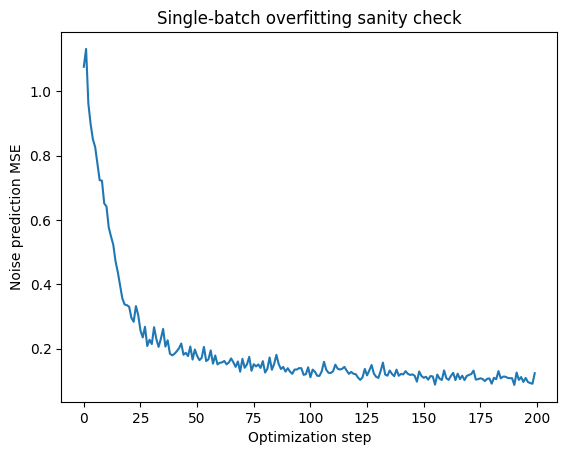

In [20]:
plt.plot(test_losses)
plt.xlabel("Optimization step")
plt.ylabel("Noise prediction MSE")
plt.title("Single-batch overfitting sanity check")
plt.show()

## Training & Validation


This part is the main training loop.

It is not a part of any class for easier check and debugging.

In [19]:
# Reinitialize model after the single-batch sanity check

unet = UNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    emb_dim=256,
)

model = ConditionalDenoiser(
    unet=unet,
    time_dim=256,
    cond_dim=16,
    emb_dim=256,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

In [20]:
# Define the number of epochs
num_epochs = 50

# Here will be saved the loss values for the plots
train_losses = []
val_losses = []

In [21]:
# Since the colab trainings can be interrupted,
# it is better to save the best checkpoints
best_val_loss = float("inf")

os.makedirs(
    "checkpoints",
    exist_ok=True
)

# For colab training (REMOVE BEFORE FINAL PUSH)
checkpoint_dir = "/content/drive/MyDrive/for_bostongene/checkpoints"

os.makedirs(
    checkpoint_dir,
    exist_ok=True
)

**Important:** Note that the validation loss has some stochasticity, since each time the algorithm samples new timesteps and noises. So the validation loss values may wiggle, even when the model is improving.

That's why an early stopping logic is not implemented here.

In [22]:
for epoch in range(num_epochs):
    # TRAINING
    start_time = time.time()
    model.train()

    epoch_train_loss = 0.0

    # For a single batch
    # (the labels are not used as expected)
    for images, cond, _ in train_loader:

        # Send the images and their conditions to the device
        images = images.to(
            device,
            non_blocking=True
        )

        cond = cond.to(
            device,
            non_blocking=True
        )

        # Normalize the condition in the device, since the mean and std are already there
        cond = normalize_condition(cond)

        # Uniformaly sample timesteps for each image and also send them to the device
        t = torch.randint(
            0,
            ddpm.timesteps,
            (images.shape[0],),
            device=device,
            dtype=torch.long,
        )

        # A usual training steps
        optimizer.zero_grad(set_to_none=True)

        loss = ddpm.training_loss(
            model,
            images,
            t,
            cond,
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        # Add the batch's loss to the epoch's loss
        epoch_train_loss += (
            loss.item() * images.shape[0]
        )

    epoch_train_loss /= len(
        train_loader.dataset
    )

    train_losses.append(
        epoch_train_loss
    )

    # After training one epoch, perform validation

    # VALIDATION
    model.eval()

    epoch_val_loss = 0.0

    with torch.no_grad():
        # Send each batch to the device
        # and further analogical to the training flow
        for images, cond, _ in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            cond = normalize_condition(
                cond.to(
                    device,
                    non_blocking=True
                )
            )

            t = torch.randint(
                0,
                ddpm.timesteps,
                (images.shape[0],),
                device=device,
                dtype=torch.long,
            )

            loss = ddpm.training_loss(
                model,
                images,
                t,
                cond,
            )

            epoch_val_loss += (
                loss.item()
                * images.shape[0]
            )

    epoch_val_loss /= len(
        val_loader.dataset
    )

    val_losses.append(
        epoch_val_loss
    )

    # If this epoch beats ther previous best model...
    if epoch_val_loss < best_val_loss:

        # ...update the new best validation loss...
        best_val_loss = epoch_val_loss

        # ...and immediately save its checkpoint!!!
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "train_loss":
                    epoch_train_loss,

                "val_loss":
                    epoch_val_loss,

                "cond_mean":
                    cond_mean.cpu(),

                "cond_std":
                    cond_std.cpu(),
            },
            #"checkpoints/best_model.pt",
            f"{checkpoint_dir}/best_model.pt"
        )

    # Save the latest model in case the training is interrupted
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": train_losses,
            "val_losses": val_losses,
            "cond_mean": cond_mean.cpu(),
            "cond_std": cond_std.cpu(),
        },
        #"checkpoints/latest_model.pt",
        f"{checkpoint_dir}/latest_model.pt"
    )

    epoch_time = time.time() - start_time

    # For the debugging purpose print the losses
    print(
        f"Epoch {epoch + 1:03d}/{num_epochs} | "
        f"Train: {epoch_train_loss:.4f} | "
        f"Val: {epoch_val_loss:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

Epoch 001/50 | Train: 0.1434 | Val: 0.0850 | Time: 63.6s
Epoch 002/50 | Train: 0.0791 | Val: 0.0724 | Time: 67.9s
Epoch 003/50 | Train: 0.0725 | Val: 0.0692 | Time: 68.1s
Epoch 004/50 | Train: 0.0689 | Val: 0.0713 | Time: 67.6s
Epoch 005/50 | Train: 0.0669 | Val: 0.0669 | Time: 68.0s
Epoch 006/50 | Train: 0.0652 | Val: 0.0639 | Time: 67.8s
Epoch 007/50 | Train: 0.0649 | Val: 0.0665 | Time: 67.5s
Epoch 008/50 | Train: 0.0631 | Val: 0.0630 | Time: 68.0s
Epoch 009/50 | Train: 0.0628 | Val: 0.0628 | Time: 68.2s
Epoch 010/50 | Train: 0.0623 | Val: 0.0641 | Time: 67.6s
Epoch 011/50 | Train: 0.0623 | Val: 0.0630 | Time: 67.5s
Epoch 012/50 | Train: 0.0620 | Val: 0.0631 | Time: 67.3s
Epoch 013/50 | Train: 0.0620 | Val: 0.0619 | Time: 68.0s
Epoch 014/50 | Train: 0.0614 | Val: 0.0626 | Time: 67.7s
Epoch 015/50 | Train: 0.0605 | Val: 0.0634 | Time: 67.6s
Epoch 016/50 | Train: 0.0614 | Val: 0.0596 | Time: 68.0s
Epoch 017/50 | Train: 0.0604 | Val: 0.0601 | Time: 67.8s
Epoch 018/50 | Train: 0.0601 | 

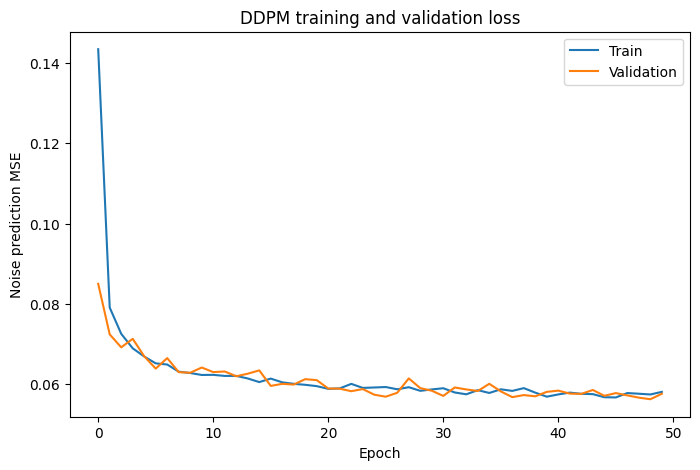

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Noise prediction MSE")
plt.title("DDPM training and validation loss")
plt.legend()

plt.show()